In [1]:
import numpy as np
import pandas as pd

In [2]:
import torch

data_path = "../data/filtered_train_test_split/"

POSITIONS = 18

X_test_tensor, y_test_tensor, test_inputs, targets = {}, {}, {}, {}

for i in range(POSITIONS):
    X_test_tensor[i] = torch.load(f"{data_path}X_test_{i}.pt")
    y_test_tensor[i] = torch.load(f"{data_path}y_test_{i}.pt")
    test_inputs[i] = pd.read_pickle(f"{data_path}X_test_{i}.pkl").tolist()
    targets[i] = pd.read_pickle(f"{data_path}y_test_{i}.pkl").tolist()


print(X_test_tensor[0][:5])
print(y_test_tensor[0][:5])
print(test_inputs[0][:5])
print(targets[0][:5])

C:\Users\gurgel\AppData\Local\Temp\ipykernel_18660\2132876398.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_test_tensor[i] = torch.load(f"{data_path}X_test_{i}.pt")

tensor([[ 4.6000e+01, -2.1376e-01, -2.7302e-01, -2.0079e-01, -2.5825e-01,
         -2.2256e-01, -2.2331e-01, -2.6441e-01, -2.9630e-01, -3.0502e-01,
         -3.1973e-01, -3.3386e-01, -4.1456e-01, -7.1675e-01, -8.0627e-01,
         -9.0755e-01, -1.0729e+00, -1.0910e+00, -1.0705e+00, -1.1417e+00,
         -1.1264e+00, -1.0887e+00, -1.0940e+00, -1.0091e+00, -9.9629e-01,
         -9.2584e-01, -8.4365e-01, -9.1054e-01, -8.1281e-01, -7.9621e-01,
         -6.8563e-01, -6.5276e-01, -6.0489e-01, -6.4545e-01, -5.5362e-01,
         -5.5409e-01, -5.8791e-01, -5.9253e-01, -5.4771e-01, -1.1744e+00,
         -1.1432e+00],
        [ 1.0000e+01, -1.2046e+00, -1.1377e+00, -1.1721e+00, -1.0619e+00,
         -9.7694e-01, -9.8520e-01, -8.2514e-01, -7.6225e-01, -7.4898e-01,
         -6.0825e-01, -7.8904e-01, -7.1147e-01, -6.8148e-01, -5.9219e-01,
         -6.5168e-01, -5.0646e-01, -4.5720e-01, -3.8838e-01, -3.0352e-01,
          6.8895e-02,  2.3324e-01,  4.0634e-01,  5.7931e-01,  6.1750e-01,
          5.780

In [3]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 512
num_workers = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

inputs, test_dataset, test_loader = {}, {}, {}

for i in range(POSITIONS):
    inputs[i] = X_test_tensor[i].shape[1]
    test_dataset[i] = TensorDataset(X_test_tensor[i], y_test_tensor[i])
    test_loader[i] = DataLoader(
        dataset=test_dataset[i],
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

print(test_loader[0].dataset.tensors)

(tensor([[46.0000, -0.2138, -0.2730,  ..., -0.5477, -1.1744, -1.1432],
        [10.0000, -1.2046, -1.1377,  ...,  0.5050, -1.1571, -1.1429],
        [33.0000, -1.7444, -1.7738,  ...,  0.8641,  1.2261,  1.2260],
        ...,
        [35.0000,  1.3852,  1.5208,  ...,  1.7421, -1.1643, -1.1480],
        [56.0000, -0.8822, -0.9156,  ...,  0.6520, -1.1681, -1.1030],
        [43.0000, -0.1381, -0.1438,  ..., -0.2081, -1.1750, -1.1440]]), tensor([0, 0, 1,  ..., 0, 0, 0]))


In [4]:
from mlp import CsiNeuralNet

models_path = "mlp/"
net: dict[int, CsiNeuralNet] = {}
prediction, accuracy = {}, {}

for i in range(POSITIONS):
    state_file = f"{models_path}filtered_model_{i}.pth"
    net[i] = CsiNeuralNet(inputs[i], device, state_file, output_dim=2)

    print(f"Model {i} loaded from {state_file}")
    prediction[i], accuracy[i] = net[i].test_model(test_loader[i])

c:\Users\gurgel\Desktop\Personal\Projects\UFF\Mestrado\Telecom\HAR\csi\models\mlp.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(state_

Model 0 loaded from mlp/filtered_model_0.pth
Testing on device: cuda
Accuracy: 99.83%, In 8.46s
Model 1 loaded from mlp/filtered_model_1.pth
Testing on device: cuda
Accuracy: 99.25%, In 7.75s
Model 2 loaded from mlp/filtered_model_2.pth
Testing on device: cuda
Accuracy: 99.27%, In 8.09s
Model 3 loaded from mlp/filtered_model_3.pth
Testing on device: cuda
Accuracy: 98.12%, In 8.33s
Model 4 loaded from mlp/filtered_model_4.pth
Testing on device: cuda
Accuracy: 99.48%, In 7.96s
Model 5 loaded from mlp/filtered_model_5.pth
Testing on device: cuda
Accuracy: 99.46%, In 7.97s
Model 6 loaded from mlp/filtered_model_6.pth
Testing on device: cuda
Accuracy: 99.00%, In 8.13s
Model 7 loaded from mlp/filtered_model_7.pth
Testing on device: cuda
Accuracy: 98.93%, In 7.99s
Model 8 loaded from mlp/filtered_model_8.pth
Testing on device: cuda
Accuracy: 99.11%, In 7.88s
Model 9 loaded from mlp/filtered_model_9.pth
Testing on device: cuda
Accuracy: 99.02%, In 7.98s
Model 10 loaded from mlp/filtered_model_

               0       1       2       3       4       5       6       7   \
Accuracy:  99.83%  99.25%  99.27%  98.12%  99.48%  99.46%  99.00%  98.93%   

               8       9       10      11      12      13      14      15  \
Accuracy:  99.11%  99.02%  99.68%  99.68%  99.70%  99.66%  98.48%  95.12%   

               16      17  
Accuracy:  94.95%  95.79%  


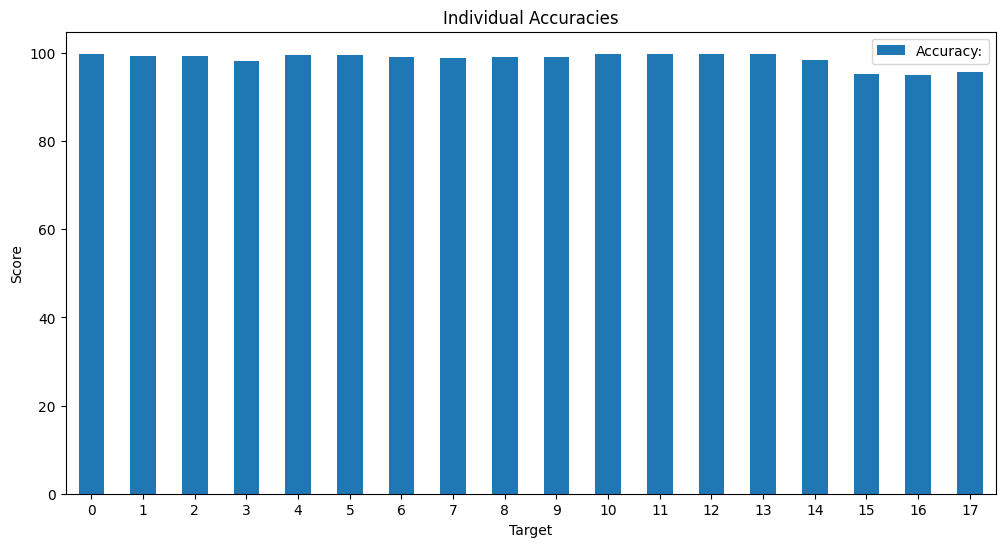

In [5]:
import matplotlib.pyplot as plt

accuracy_data = {"Accuracy:": accuracy}
accuracy_df = pd.DataFrame(accuracy_data) * 100
accuracy_df.plot(kind="bar", figsize=(12, 6))

accuracy_df = accuracy_df.map("{:.2f}%".format)
print(accuracy_df.T)

plt.title("Individual Accuracies")
plt.xlabel("Target")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.show()

In [7]:
num_positions = POSITIONS

sum_probabilities = [0.0] * num_positions
sum_correct_probabilities = [0.0] * num_positions
sum_wrong_probabilities = [0.0] * num_positions
prediction_counts = [0] * num_positions
correct_counts = [0] * num_positions
wrong_counts = [0] * num_positions

num_bins = 101
total_bins = [0] * num_bins
total_correct_bins = [0] * num_bins
pos_bins = [[0] * num_bins for _ in range(num_positions)]
pos_correct_bins = [[0] * num_bins for _ in range(num_positions)]

for i in range(POSITIONS):
    for x, y in zip(test_inputs[i], targets[i]):
        state = torch.tensor([x], dtype=torch.float32).to(device)
        net[i].to(device)
        probabilities = net[i].get_position_probabilities(state)

        max_prob = max(probabilities)
        prediction = probabilities.index(max_prob)

        prediction_counts[i] += 1
        sum_probabilities[i] += max_prob

        bin_index = int(max_prob * 100)
        total_bins[bin_index] += 1
        pos_bins[i][bin_index] += 1

        if prediction == y:
            sum_correct_probabilities[i] += max_prob
            correct_counts[i] += 1
            total_correct_bins[bin_index] += 1
            pos_correct_bins[i][bin_index] += 1
        else:
            sum_wrong_probabilities[i] += max_prob
            wrong_counts[i] += 1

In [8]:
average_total_probabilities = []
average_correct_probabilities = []
average_wrong_probabilities = []

for i in range(num_positions):
    average_total_probabilities.append(
        sum_probabilities[i] / prediction_counts[i] if prediction_counts[i] != 0 else 0
    )
    average_correct_probabilities.append(
        sum_correct_probabilities[i] / correct_counts[i]
        if correct_counts[i] != 0
        else 0
    )
    average_wrong_probabilities.append(
        sum_wrong_probabilities[i] / wrong_counts[i] if wrong_counts[i] != 0 else 0
    )

print(average_total_probabilities)
print(average_correct_probabilities)
print(average_wrong_probabilities)

[0.999770219759723, 0.9955998549057878, 0.9954529757827343, 0.9894476341312496, 0.9976500670306725, 0.9969201835754437, 0.9940441354384894, 0.9938022978984515, 0.9944448720699336, 0.9943048033679633, 0.9986831880295668, 0.9988645958922671, 0.998831402549509, 0.9983849181449614, 0.9898674262759404, 0.9617495741160442, 0.9612383434828186, 0.971489094090361]
[0.9998673686041225, 0.9968541027645407, 0.9966839778543608, 0.9922761057145725, 0.9984169141895806, 0.9977576054071181, 0.9957323116161607, 0.9956432196739188, 0.9960090971670543, 0.9959752249427339, 0.9991041833320367, 0.9992124473906021, 0.9992080264573105, 0.9988483701715204, 0.9921783833100887, 0.9712365502936867, 0.9709789652917139, 0.9783914330223764]
[0.9423781112712972, 0.8290092945297096, 0.8287100091793853, 0.8417833164604225, 0.852101458170336, 0.8412417925572429, 0.826620513285337, 0.8233271176855518, 0.8202848707344996, 0.8249811670216736, 0.8660260138788846, 0.8901973049217295, 0.8758935752780191, 0.8616201910049798, 0.

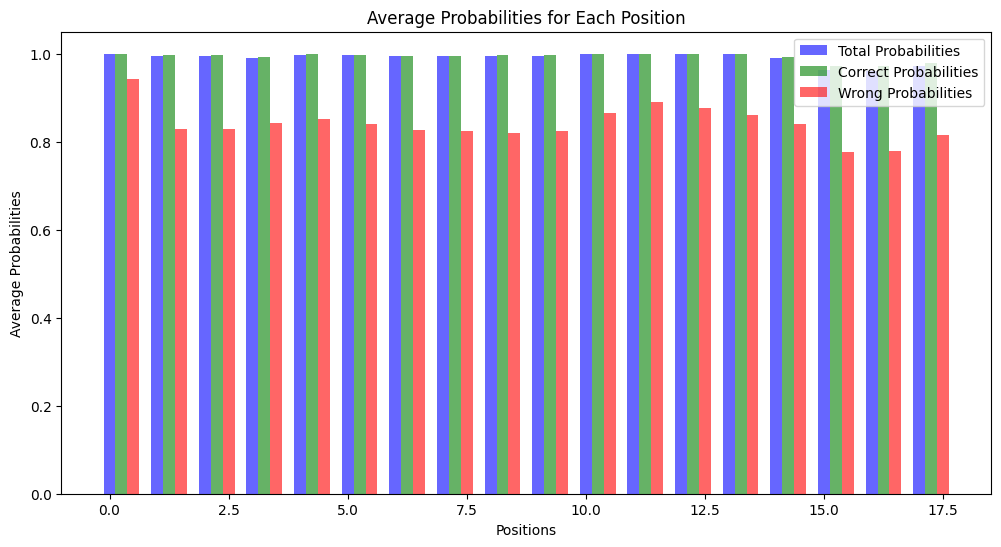

In [10]:
bar_width = 0.25

positions = np.arange(num_positions)
positions_total = positions
positions_correct = positions + bar_width
positions_wrong = positions + 2 * bar_width

plt.figure(figsize=(12, 6))
plt.bar(
    positions_total,
    average_total_probabilities,
    width=bar_width,
    color="blue",
    alpha=0.6,
    label="Total Probabilities",
)
plt.bar(
    positions_correct,
    average_correct_probabilities,
    width=bar_width,
    color="green",
    alpha=0.6,
    label="Correct Probabilities",
)
plt.bar(
    positions_wrong,
    average_wrong_probabilities,
    width=bar_width,
    color="red",
    alpha=0.6,
    label="Wrong Probabilities",
)
plt.xlabel("Positions")
plt.ylabel("Average Probabilities")
plt.title("Average Probabilities for Each Position")
plt.legend()
plt.show()

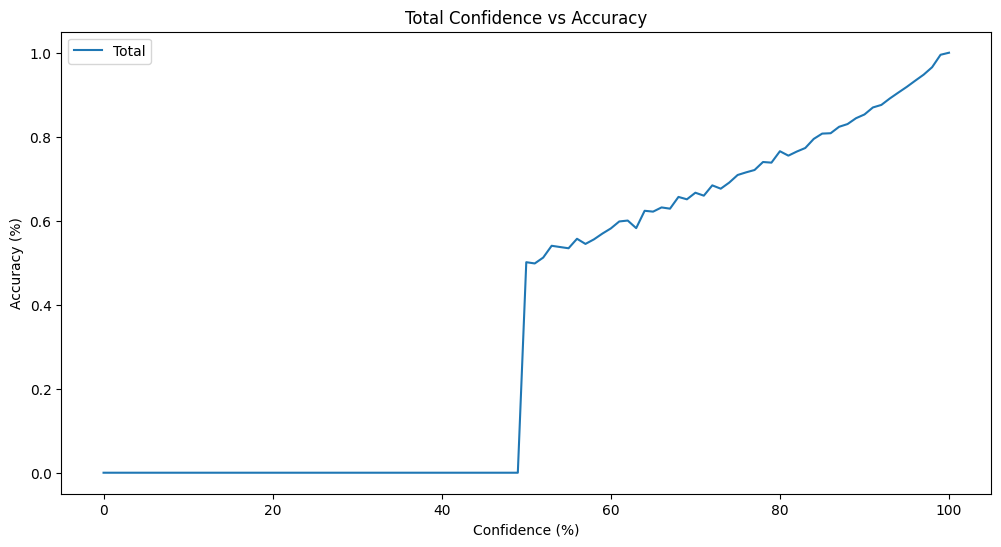

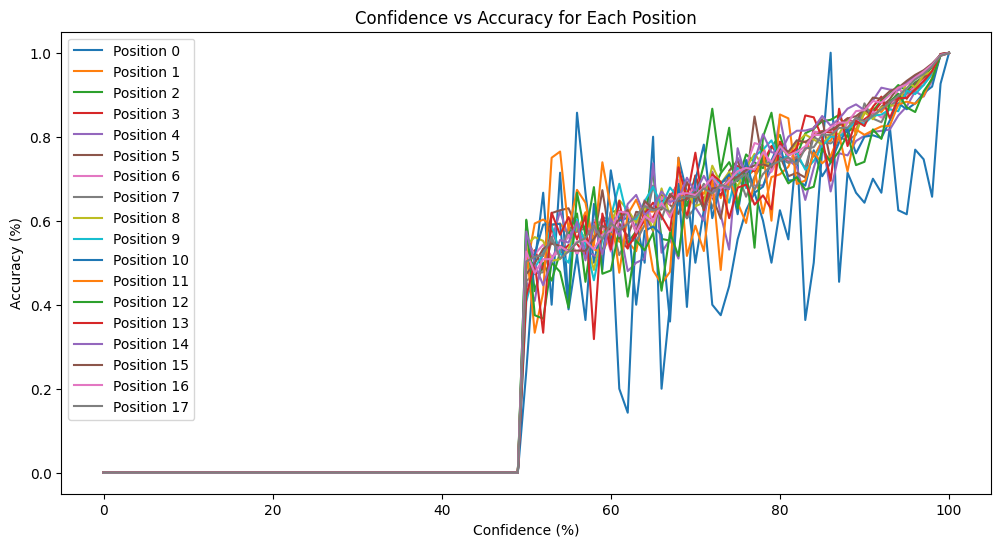

In [12]:
total_accuracy_bins = [0] * num_bins
pos_accuracy_bins = [[0] * num_bins for _ in range(num_positions)]

for i in range(num_bins):
    total_accuracy_bins[i] = (
        total_correct_bins[i] / total_bins[i] if total_bins[i] != 0 else 0
    )
    for j in range(num_positions):
        pos_accuracy_bins[j][i] = (
            pos_correct_bins[j][i] / pos_bins[j][i] if pos_bins[j][i] != 0 else 0
        )

# Plot the total confidence/accuracy relation
plt.figure(figsize=(12, 6))
plt.plot(range(num_bins), total_accuracy_bins, label="Total")
plt.xlabel("Confidence (%)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Total Confidence vs Accuracy")
plt.show()

# Plot the confidence/accuracy relation for each individual position
plt.figure(figsize=(12, 6))
for pos in range(num_positions):
    plt.plot(range(num_bins), pos_accuracy_bins[pos], label=f"Position {pos}")
plt.xlabel("Confidence (%)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Confidence vs Accuracy for Each Position")
plt.show()